# 02417 — Time Series Analysis — Assignment 1

**Dataset:** Statistics Denmark (BIL54) — number of motor driven vehicles (monthly)  



## 0) Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=6, suppress=True)


## 1) Load data

In [2]:
csv_path = "DST_BIL54.csv"

if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Could not find {csv_path}. Put DST_BIL54.csv next to this notebook or update csv_path."
    )

df = pd.read_csv(csv_path)

display(df.head())
display(df.tail())
print("Columns:", list(df.columns))
print("Rows:", len(df))


,time,total,gasoline,diesel,fgas,ngas,electricity,petroleum,hydrogen,methanol,ethanol,pluginhybrid,otherfuels
0,2018-01,2930483,1781826,1136656,12,256,9304,0,81,0,0,2340,8
1,2018-02,2934044,1783338,1138414,12,255,9343,0,80,0,0,2593,9
2,2018-03,2941422,1787219,1141576,12,257,9399,0,77,0,0,2873,9
3,2018-04,2951498,1793554,1144846,12,257,9548,0,77,0,0,3195,9
4,2018-05,2963093,1799795,1149840,12,256,9665,0,77,0,0,3439,9


,time,total,gasoline,diesel,fgas,ngas,electricity,petroleum,hydrogen,methanol,ethanol,pluginhybrid,otherfuels
79,2024-08,3258060,1812725,1020346,17,518,295273,0,22,0,0,129145,14
80,2024-09,3256515,1803995,1012530,16,527,310130,0,21,0,0,129282,14
81,2024-10,3252275,1793968,1002291,18,529,325966,0,21,0,0,129468,14
82,2024-11,3253059,1787081,994990,19,521,340812,0,21,0,0,129601,14
83,2024-12,3258025,1782430,987726,19,519,357317,0,21,0,0,129979,14


Columns: ['time', 'total', 'gasoline', 'diesel', 'fgas', 'ngas', 'electricity', 'petroleum', 'hydrogen', 'methanol', 'ethanol', 'pluginhybrid', 'otherfuels']
Rows: 84


## 2) Build a continuous time variable and train/test split

In [3]:
def _find_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

year_col = _find_col(["year", "Year", "YEAR", "år", "Aar", "År"])
month_col = _find_col(["month", "Month", "MONTH", "mnd", "Mnd", "måned", "Måned"])
value_col = _find_col(["value", "Value", "VALUE", "vehicles", "Vehicles", "TOTAL", "Total", "total"])
time_col = _find_col(["time", "Time", "TIME", "tid", "Tid"])

if value_col is None:
    value_col = df.columns[-1]

if time_col is not None and (year_col is None or month_col is None):
    t = df[time_col].astype(str)
    year = t.str.extract(r"(\d{4})")[0].astype(int)
    month = t.str.extract(r"(?:M|[-/])(\d{1,2})")[0].astype(int)
else:
    if year_col is None or month_col is None:
        raise ValueError(
            "Could not infer year/month columns. Please rename columns or adapt the parsing cell."
        )
    year = df[year_col].astype(int)
    month = df[month_col].astype(int)

y = df[value_col].astype(float).to_numpy()

# x = year + (month-1)/12
x = year.to_numpy() + (month.to_numpy() - 1) / 12.0

data = (
    pd.DataFrame({"year": year, "month": month, "x": x, "y": y})
    .sort_values(["year", "month"])
    .reset_index(drop=True)
)

train = data[(data["year"] >= 2018) & (data["year"] <= 2023)].copy()
test = data[(data["year"] == 2024)].copy()

N = len(train)
print("Train N =", N, "| Test N =", len(test))
display(train.head())
display(train.tail())


Train N = 72 | Test N = 12


,year,month,x,y
0,2018,1,2018.000000,2930483.0
1,2018,2,2018.083333,2934044.0
2,2018,3,2018.166667,2941422.0
3,2018,4,2018.250000,2951498.0
4,2018,5,2018.333333,2963093.0


,year,month,x,y
67,2023,8,2023.583333,3228835.0
68,2023,9,2023.666667,3226588.0
69,2023,10,2023.750000,3220559.0
70,2023,11,2023.833333,3221920.0
71,2023,12,2023.916667,3227541.0


**Interpretation:**  
- `x` is the continuous time variable used for regression.  
- `train` contains 2018–2023 (typically **N = 72** months).  
- `test` contains 2024 months for out-of-sample evaluation.

## 3) Plot training data

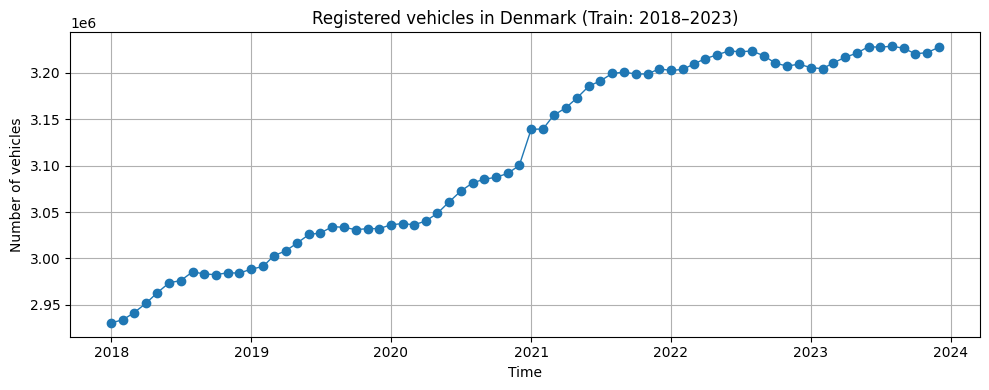

In [4]:
train_dates = pd.to_datetime(
    train["year"].astype(str) + "-" + train["month"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(10, 4))
plt.plot(train_dates, train["y"], marker="o", linewidth=1)
plt.title("Registered vehicles in Denmark (Train: 2018–2023)")
plt.xlabel("Time")
plt.ylabel("Number of vehicles")
plt.tight_layout()
plt.show()


**Interpretation:**  
You should see an overall increasing trend. If the curve flattens in later years or shows a jump around 2020–2021, that suggests the trend is not perfectly linear over the full period.

## 4) OLS: global linear trend

In [5]:
X_train = np.column_stack([np.ones(N), train["x"].to_numpy()])
Y_train = train["y"].to_numpy()

theta_ols, *_ = np.linalg.lstsq(X_train, Y_train, rcond=None)

yhat_train_ols = X_train @ theta_ols
resid_ols = Y_train - yhat_train_ols

print("theta_ols =", theta_ols)
print("Train residual mean (should be ~0):", resid_ols.mean())


theta_ols = [-1.103554e+08  5.614456e+04]
Train residual mean (should be ~0): 6.20881716410319e-09


**Interpretation:**  
- `theta_ols[0]` is the intercept, `theta_ols[1]` is the slope (trend).  
- Residual mean should be close to zero (a quick sanity check).

## 5) OLS forecast for 2024

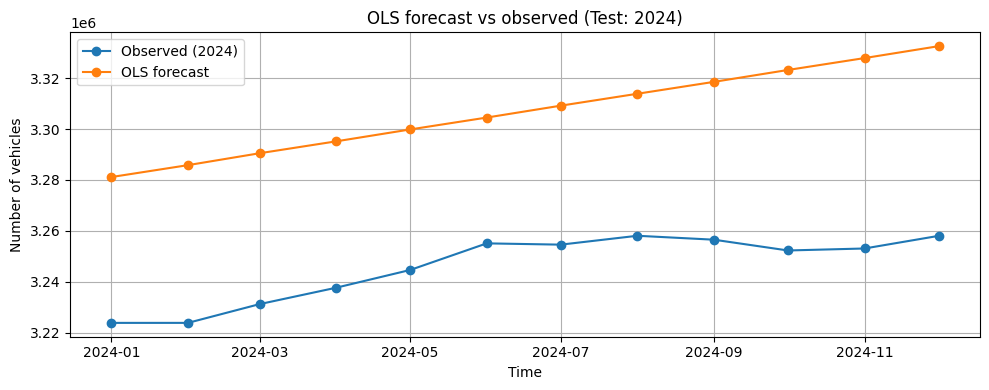

MAE = 61170.04406766221
RMSE = 61671.80345638725


In [6]:
X_test = np.column_stack([np.ones(len(test)), test["x"].to_numpy()])
Y_test = test["y"].to_numpy()

yhat_test_ols = X_test @ theta_ols

test_dates = pd.to_datetime(
    test["year"].astype(str) + "-" + test["month"].astype(str).str.zfill(2) + "-01"
)

plt.figure(figsize=(10, 4))
plt.plot(test_dates, Y_test, marker="o", label="Observed (2024)")
plt.plot(test_dates, yhat_test_ols, marker="o", label="OLS forecast")
plt.title("OLS forecast vs observed (Test: 2024)")
plt.xlabel("Time")
plt.ylabel("Number of vehicles")
plt.legend()
plt.tight_layout()
plt.show()

mae = np.mean(np.abs(Y_test - yhat_test_ols))
rmse = np.sqrt(np.mean((Y_test - yhat_test_ols) ** 2))
print("MAE =", mae)
print("RMSE =", rmse)


**Interpretation:**  
If the OLS line misses changes in growth rate (e.g., jump/leveling), the forecast can drift away from observations. MAE/RMSE summarize the typical error size in 2024.

## 6) OLS residual diagnostics

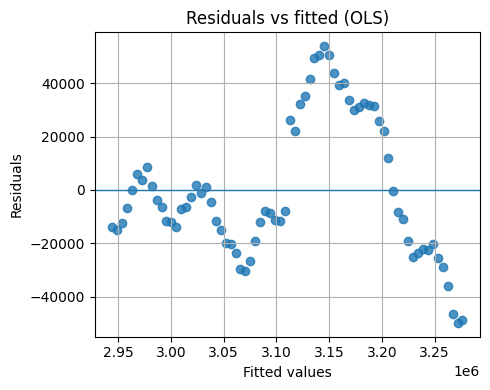

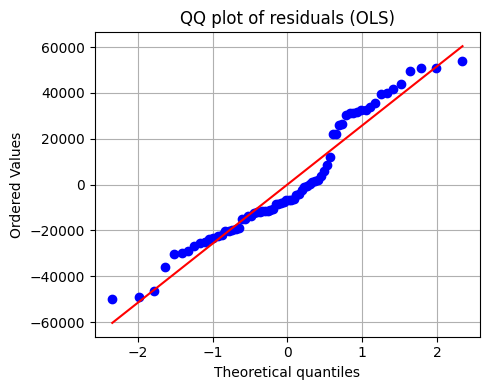

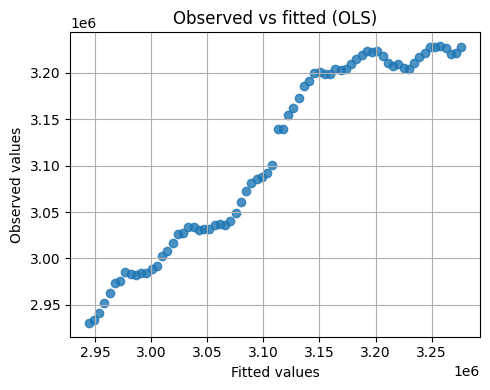

In [7]:
plt.figure(figsize=(5, 4))
plt.scatter(yhat_train_ols, resid_ols, alpha=0.8)
plt.axhline(0, linewidth=1)
plt.title("Residuals vs fitted (OLS)")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
stats.probplot(resid_ols, dist="norm", plot=plt)
plt.title("QQ plot of residuals (OLS)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(yhat_train_ols, Y_train, alpha=0.8)
plt.title("Observed vs fitted (OLS)")
plt.xlabel("Fitted values")
plt.ylabel("Observed values")
plt.tight_layout()
plt.show()


**Interpretation:**  
- Residuals vs fitted: random scatter around 0 is good; visible structure suggests missing behavior (nonlinearity or time dependence).  
- QQ plot: strong deviations from a straight line suggest residuals are not Normal.  
- Observed vs fitted: tighter clustering means a better fit.

## 7) Autocorrelation of OLS residuals (ACF/PACF)

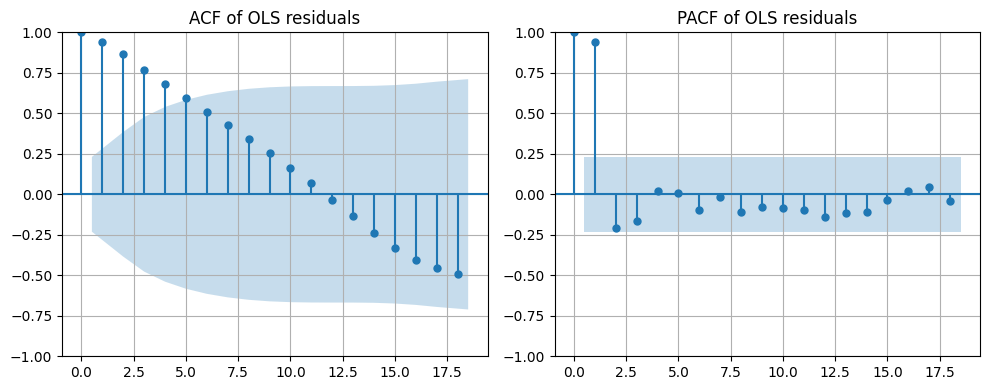

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(resid_ols, lags=18, ax=ax[0])
plot_pacf(resid_ols, lags=18, ax=ax[1], method="ywm")
ax[0].set_title("ACF of OLS residuals")
ax[1].set_title("PACF of OLS residuals")
plt.tight_layout()
plt.show()


**Interpretation:**  
- Slow decay in ACF often points to AR-type dependence.  
- A strong PACF spike at lag 1 with later lags small is a classic sign of AR(1)-like behavior.

## 8) WLS: local linear trend with exponential forgetting

lambda = 0.9
Effective total weight T = 9.994924712139436


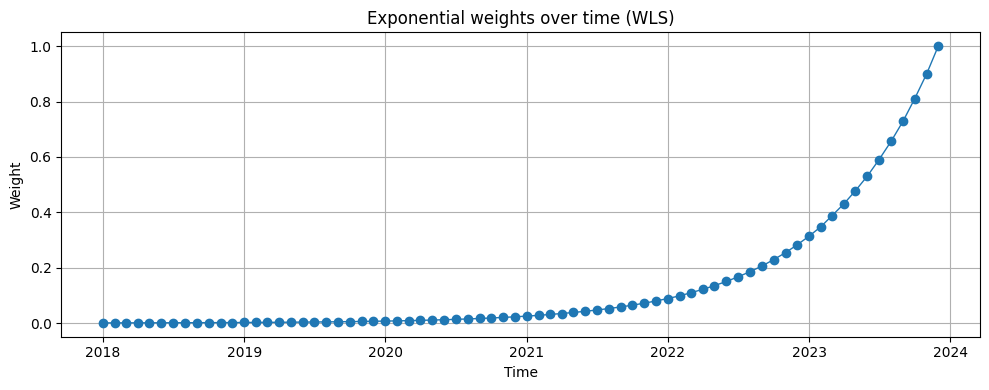

In [9]:
lam = 0.9

# Newest observation gets weight 1, older observations get exponentially smaller weights
j = np.arange(N - 1, -1, -1)  # newest -> 0, oldest -> N-1
w = lam ** j

T = w.sum()
print("lambda =", lam)
print("Effective total weight T =", T)

plt.figure(figsize=(10, 4))
plt.plot(train_dates, w, marker="o", linewidth=1)
plt.title("Exponential weights over time (WLS)")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


**Interpretation:**  
Weights should increase toward the end of the training period (recent months). For \(\lambda=0.9\), the effective total weight \(T\) is much smaller than \(N\), meaning the fit is driven mainly by recent observations.

## 9) Fit WLS parameters (same linear model, weighted)

In [10]:
W = np.diag(w)
XtW = X_train.T @ W
theta_wls = np.linalg.inv(XtW @ X_train) @ (XtW @ Y_train)

yhat_train_wls = X_train @ theta_wls
resid_wls = Y_train - yhat_train_wls

print("theta_wls =", theta_wls)


theta_wls = [-52482861.886719     27529.901619]


**Interpretation:**  
`theta_wls` is still an intercept + slope, but chosen to match the recent part of the training set more closely.

## 10) Forecast comparison: OLS vs WLS on 2024

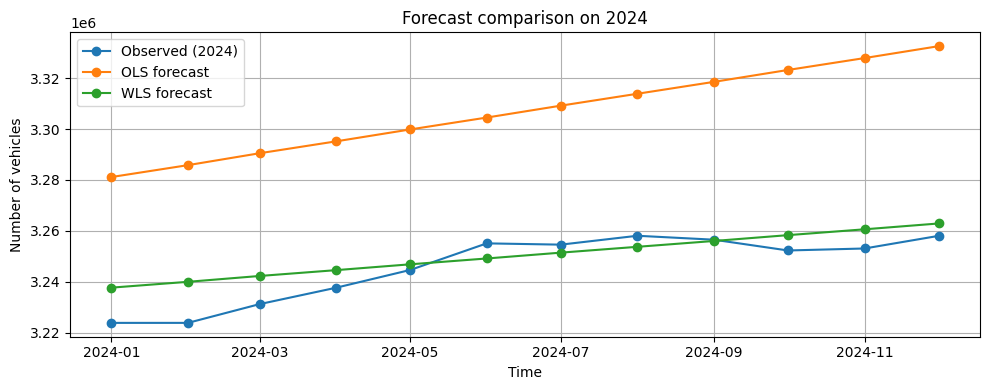

OLS -> MAE: 61170.04406766221 RMSE: 61671.80345638725
WLS -> MAE: 6882.43156337738 RMSE: 8212.668733563185


In [11]:
yhat_test_wls = X_test @ theta_wls

plt.figure(figsize=(10, 4))
plt.plot(test_dates, Y_test, marker="o", label="Observed (2024)")
plt.plot(test_dates, yhat_test_ols, marker="o", label="OLS forecast")
plt.plot(test_dates, yhat_test_wls, marker="o", label="WLS forecast")
plt.title("Forecast comparison on 2024")
plt.xlabel("Time")
plt.ylabel("Number of vehicles")
plt.legend()
plt.tight_layout()
plt.show()

mae_ols = np.mean(np.abs(Y_test - yhat_test_ols))
rmse_ols = np.sqrt(np.mean((Y_test - yhat_test_ols) ** 2))

mae_wls = np.mean(np.abs(Y_test - yhat_test_wls))
rmse_wls = np.sqrt(np.mean((Y_test - yhat_test_wls) ** 2))

print("OLS -> MAE:", mae_ols, "RMSE:", rmse_ols)
print("WLS -> MAE:", mae_wls, "RMSE:", rmse_wls)


**Interpretation:**  
If the series changes behavior over time, WLS can sometimes improve the 2024 forecast because it “trusts” the most recent training pattern more.

## 11) Sum of weights and WLS variance estimate

In [12]:
T_ols = N
print("T (WLS) =", T)
print("T (OLS) =", T_ols)

p = X_train.shape[1]

sigma2_wls = (resid_wls.T @ W @ resid_wls) / (T - p)
sigma2_ols = (resid_ols.T @ resid_ols) / (N - p)

print("p =", p)
print("sigma2_ols =", sigma2_ols)
print("sigma2_wls =", sigma2_wls)


T (WLS) = 9.994924712139436
T (OLS) = 72
p = 2
sigma2_ols = 682825663.1928633
sigma2_wls = 341489986.7742041


**Interpretation:**  
- OLS uses \(N-p\) in the denominator (full memory).  
- WLS uses \(T-p\), where \(T\) can be much smaller than \(N\).  
This reflects fewer “effective observations” when older points are down-weighted.

## 12) WLS residual autocorrelation (optional check)

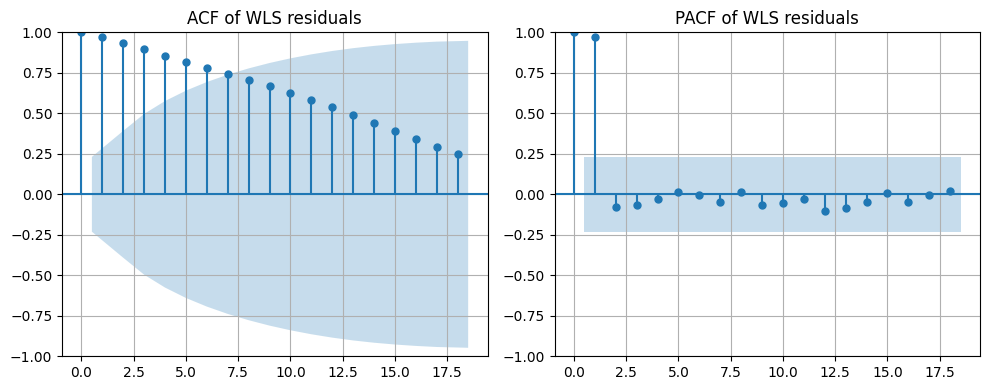

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(resid_wls, lags=18, ax=ax[0])
plot_pacf(resid_wls, lags=18, ax=ax[1], method="ywm")
ax[0].set_title("ACF of WLS residuals")
ax[1].set_title("PACF of WLS residuals")
plt.tight_layout()
plt.show()


**Interpretation:**  
If ACF/PACF still shows strong dependence, re-weighting alone may not be enough; you would typically move to a model that explicitly captures AR structure in the errors.